In [57]:
import kagglehub

path = kagglehub.dataset_download("austinreese/trump-tweets")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'trump-tweets' dataset.
Path to dataset files: /kaggle/input/trump-tweets


In [58]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor

# 1. Wczytanie danych
file_path = '/kaggle/input/trump-tweets/realdonaldtrump.csv'
df = pd.read_csv(file_path)

# 2. Czyszczenie i przygotowanie zbioru
# Usuwamy braki danych w kluczowych kolumnach (ignorujemy id, link, favorites, mentions, hashtags)
df = df.dropna(subset=['content', 'retweets'])
df['retweets'] = pd.to_numeric(df['retweets'], errors='coerce')
df = df.dropna(subset=['retweets'])

# Funkcja do podstawowego czyszczenia tekstu
def clean_text(text):
    # Usunięcie linków
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    # Usunięcie oznaczeń użytkowników i hashy (usuwamy tylko znak @ i #, słowa zostają)
    text = re.sub(r'\@|\#', '', text)
    # Usunięcie znaków interpunkcyjnych i sprowadzenie do małych liter
    text = re.sub(r'[^\w\s]', '', text)


    # USUNIĘCIE realdonaldtrump
    text = re.sub(r'\brealdonaldtrump\b', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\s+', ' ', text).strip()


    return text.lower()

df['clean_content'] = df['content'].apply(clean_text)

# 3. Transformacja zmiennej celu
# Używamy log(1 + x), aby znormalizować silnie prawoskośny rozkład retweetów
y = np.log1p(df['retweets'])
X = df['clean_content']

# 4. Podział na zbiór treningowy i testowy (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Ekstrakcja cech z tekstu (TF-IDF)
# Tworzymy reprezentację wyłącznie na podstawie słów występujących w tweecie
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', min_df=5)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"Kształt macierzy treningowej TF-IDF: {X_train_vec.shape}")

# 6. Budowa i trening modelu XGBoost
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

# # 6. Budowa i trening modelu Random Forest
# # Zastosowano n_jobs=-1, co jest kluczowe, aby zrównoleglić budowę drzew na wszystkie rdzenie
# model = RandomForestRegressor(
#     n_estimators=150,     # Liczba drzew w lesie
#     max_depth=15,         # Ograniczenie głębokości zapobiega przeuczeniu i przyspiesza SHAP
#     min_samples_split=5,  # Minimalna liczba próbek wymagana do podziału węzła
#     random_state=42,
#     n_jobs=-1             # Użycie wszystkich dostępnych rdzeni CPU
# )

print("Rozpoczęto trening modelu...")
model.fit(X_train_vec, y_train)
print("Trening zakończony.")

# 7. Ewaluacja modelu
y_pred_log = model.predict(X_test_vec)

# Ewaluacja w przestrzeni zlogarytmowanej
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
r2 = r2_score(y_test, y_pred_log)

print("\n--- Wyniki ewaluacji (skala logarytmiczna) ---")
print(f"RMSE (Log): {rmse_log:.4f}")
print(f"R2 Score:   {r2:.4f}")

# Obliczenie MAE w oryginalnej przestrzeni (odwrócenie logarytmu)
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(y_pred_log)

mae_orig = mean_absolute_error(y_test_orig, y_pred_orig)
print(f"\n--- Średni błąd absolutny (MAE) w rzeczywistych retweetach ---")
print(f"MAE: ~{int(mae_orig)} retweetów")




Kształt macierzy treningowej TF-IDF: (34681, 5000)
Rozpoczęto trening modelu...
Trening zakończony.

--- Wyniki ewaluacji (skala logarytmiczna) ---
RMSE (Log): 2.1241
R2 Score:   0.4912

--- Średni błąd absolutny (MAE) w rzeczywistych retweetach ---
MAE: ~5205 retweetów



Analizowany tweet (indeks 10):
wwinmill canada loves you donald thanks


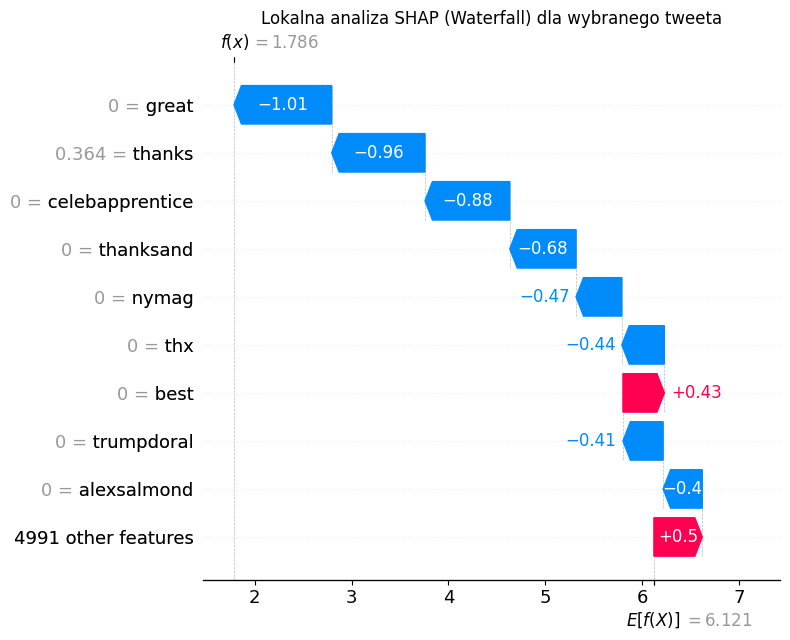

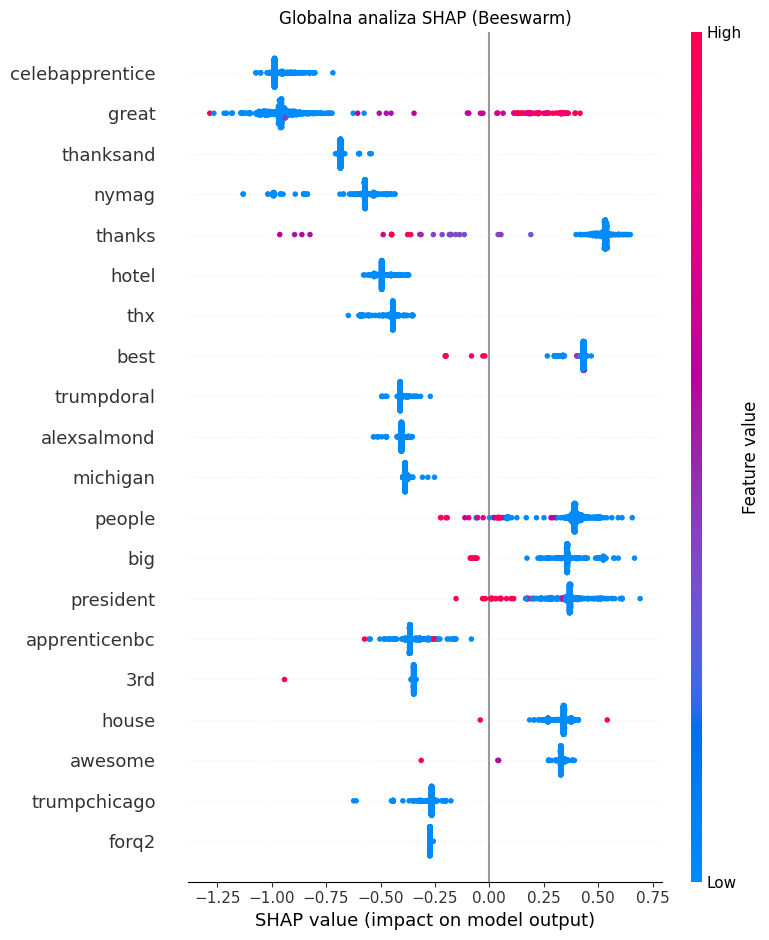

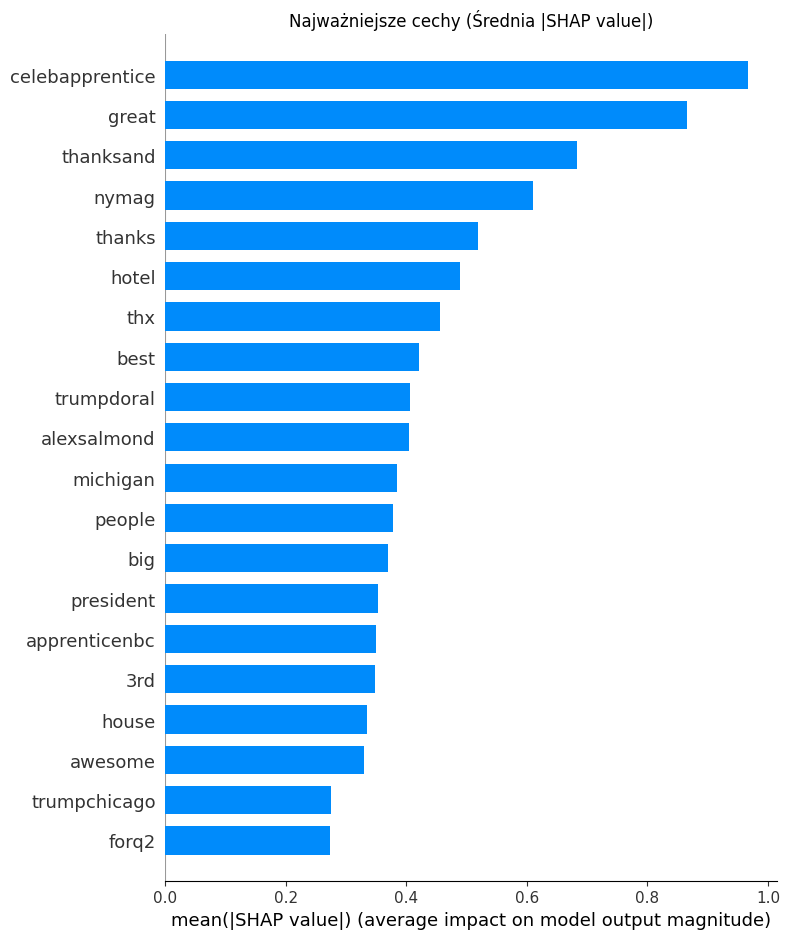

In [59]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# 1. Inicjalizacja środowiska SHAP (przydatne, jeśli używasz Jupyter Notebook)
shap.initjs()

# 2. Wybór próbki do analizy
# Ze względu na złożoność obliczeniową, wybieramy np. 500 pierwszych tweetów ze zbioru testowego.
# Przekształcamy macierz rzadką do gęstej (.toarray()), co ułatwia działanie biblioteki SHAP.
X_test_sample = X_test_vec[:500].toarray()
X_test_texts = X_test.iloc[:500]

# 3. Inicjalizacja TreeExplainer
# TreeExplainer jest zoptymalizowany dla modeli opartych na drzewach (XGBoost, Random Forest)
# print("Inicjalizacja eksploratora SHAP (TreeExplainer)...")
explainer = shap.TreeExplainer(model)

# 4. Obliczenie wartości SHAP dla próbki
# print("Obliczanie wartości SHAP (to może potrwać chwilę)...")
shap_values = explainer.shap_values(X_test_sample)

# Pobranie słownika z TF-IDF (nazwy kolumn)
feature_names = vectorizer.get_feature_names_out()

#--------------------------------------szukanie indeksu

# y_test_sample_values = y_test.iloc[:500].values

# # np.argsort sortuje rosnąco, więc odwracamy [::-1], by mieć malejąco i pobieramy 10 pierwszych
# top_10_positional_indices = np.argsort(y_test_sample_values)[::-1][:10]

# print("\n--- Najpopularniejsze tweety w badanej próbce SHAP (Top 10) ---")
# print("Indeksy Top 10 (do zmiennej 'idx'):", top_10_positional_indices.tolist())

#---------------------------------------------------


# ==========================================
# WIZUALIZACJE (do umieszczenia w sprawozdaniu)
# ==========================================

# Wykres 1: Wykres kaskadowy (Waterfall Plot) dla POJEDYNCZEGO tweeta (Lokalna interpretacja)
# Pokazuje, jak poszczególne słowa w konkretnym tweecie złożyły się na jego wynik.
idx = 10 # Zmień indeks, aby przeanalizować inne tweety
print(f"\nAnalizowany tweet (indeks {idx}):\n{X_test_texts.iloc[idx]}")

# Przygotowanie obiektu Explanation dla nowszych wersji biblioteki SHAP
expected_value = explainer.expected_value
# W zależności od wersji sklearn/shap expected_value może być tablicą lub skalarem
if isinstance(expected_value, np.ndarray):
    expected_value = expected_value[0]

explanation = shap.Explanation(
    values=shap_values[idx],
    base_values=expected_value,
    data=X_test_sample[idx],
    feature_names=feature_names
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(explanation, max_display=10, show=False)
plt.title("Lokalna analiza SHAP (Waterfall) dla wybranego tweeta")
plt.tight_layout()
plt.show()

# Wykres 2: Wykres punktowy podsumowujący (Summary Plot / Beeswarm) - Globalna interpretacja
# Pokazuje wpływ najważniejszych słów na predykcję na przestrzeni całej badanej próbki.
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, feature_names=feature_names, show=False)
plt.title("Globalna analiza SHAP (Beeswarm)")
plt.tight_layout()
plt.show()

# Wykres 3: Wykres słupkowy (Bar Plot) - Globalna ważność cech
# Uśredniona absolutna wartość wpływu danego słowa.
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, feature_names=feature_names, plot_type="bar", show=False)
plt.title("Najważniejsze cechy (Średnia |SHAP value|)")
plt.tight_layout()
plt.show()